# The probe: where it attaches and what it does

This is the intellectual core of the project, so it gets its own notebook.

PSBD detects a backdoor by perturbing a model at inference time and watching how
much its confidence in its own prediction drops. Porting it from ConvNets to
transformers forces a question the original method never had to answer: a
ConvNet's dropout goes on the feature map, but a transformer block has a dozen
distinct places a perturbation could be injected, and they are not equivalent.

That splits the design into 2 independent axes:

- **where**, the position a probe attaches, handled by `psbd.positions`
- **what**, the operator that perturbs the tensor there, handled by `psbd.operators`

The measured result is that where dominates what: over the swept grid the range
of mean AUROC across positions is about 1.43 times the range across operators.
That ratio is computed in `notebooks/09-placement-search.ipynb` from the cached
sweep, not here. The code is factored to say the same thing out loud: the 2 axes
live in 2 modules and are combined only at the call site.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in psbd resolves the same
# way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import torch

from psbd.operators import (
    DETERMINISTIC_PERTURBATIONS,
    PERTURBATION_POSITIONS,
    PERTURBATIONS,
    build_perturbation,
)
from psbd.positions import (
    BLOCK_TYPES,
    POSITION_REGISTRY,
    SINGLE_POSITION_NAMES,
    plug_dropout,
    unplug_dropout,
)

import logging

# compute_dropout_pass_probs reseeds on every call, and Lightning announces each
# one. In a sweep that is hundreds of identical lines between the results.
logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)

torch.manual_seed(0)
print("device:", "cuda" if torch.cuda.is_available() else "cpu")

device: cuda


## Part 1. Where a probe can attach

`POSITION_REGISTRY` is one table per architecture. Each entry says which submodule
to attach to, whether to perturb its input or its output, and whether the position
repeats per block or exists once for the whole model.

In [2]:
position_rows = [
    {
        "architecture": architecture,
        "position": name,
        "submodule": spec.submodule_name or "(the block itself)",
        "hook_type": spec.hook_type,
        "scope": spec.scope,
    }
    for architecture, positions in POSITION_REGISTRY.items()
    for name, spec in positions.items()
]
positions_frame = pd.DataFrame(position_rows)
positions_frame

,architecture,position,submodule,hook_type,scope
0,vit,after_embedding,encoder.dropout,pre,model
1,vit,before_attention_norm,ln_1,pre,block
2,vit,before_attention,self_attention,pre,block
3,vit,attention_heads,self_attention,attention,block
4,vit,before_attention_residual,dropout,post,block
5,vit,before_mlp_norm,ln_2,pre,block
6,vit,after_attention_residual,(the block itself),residual,block
7,vit,before_mlp,mlp,pre,block
8,vit,mlp_neurons,mlp.3,pre,block
9,vit,before_mlp_residual,mlp,post,block


### The anatomy a position refers to

A ViT-B/16 encoder block, in forward order. The arrows are the residual stream and
the indented lines are the positions that attach at each point.

```
x ----------------------------------------------.        before_attention_norm
|                                                |         (input to ln_1)
ln_1(x)                                          |        before_attention
|                                                |         (input to self_attention)
self_attention(...)                              |        attention_heads
|                                                |         (inside the head axis)
dropout                                          |        before_attention_residual
|                                                |         (output of that dropout)
+<-----------------------------------------------'
|
x2 ---------------------------------------------.         after_attention_residual
|                                                |         (the stream after the add)
ln_2(x2)                                         |        before_mlp_norm, before_mlp
|                                                |
mlp(...)                                         |        mlp_neurons, before_mlp_residual
|                                                |
+<-----------------------------------------------'
|
block output                                              after_mlp_residual
```

Two of these cannot be expressed as a hook, and that is a fact about PyTorch
rather than a design choice. `after_attention_residual` names the tensor between
the attention add and its 2 consumers, and `attention_heads` names the per-head
outputs inside `F.multi_head_attention_forward`. Neither ever crosses a module
boundary, so no hook can see them. Both use a removable per-instance forward
wrapper instead, which mutates no weights.

`SINGLE_POSITION_NAMES` is the subset swept in isolation, listed in forward order.

In [3]:
for order, name in enumerate(SINGLE_POSITION_NAMES, start=1):
    spec = POSITION_REGISTRY["vit"][name]
    print(f"{order:2d}. {name:30s} {spec.hook_type:9s} {spec.scope}")

 1. after_embedding                pre       model
 2. before_attention_norm          pre       block
 3. before_attention               pre       block
 4. before_attention_residual      post      block
 5. after_attention_residual       residual  block
 6. before_mlp_norm                pre       block
 7. before_mlp                     pre       block
 8. before_mlp_residual            post      block
 9. after_mlp_residual             post      block


### Attaching and detaching leaves the model exactly as it was

The probe is temporary. `plug_dropout` attaches a fresh module at every match and
`unplug_dropout` removes by handle, so nothing about the loaded weights changes.
That property is load bearing: if a probe leaked, every later measurement would
silently carry it, and the symptom would be a plausible number rather than a
crash.

In [4]:
import torchvision.transforms.v2 as transforms_v2
from torchvision.models import VisionTransformer

network = VisionTransformer(
    image_size=32, patch_size=16, num_layers=2, num_heads=2,
    hidden_dim=16, mlp_dim=32, num_classes=10,
)

# torchvision zero-initializes the classification head, so an untrained
# VisionTransformer returns the same all-zero logits for every input. Comparing
# logits on one would show no effect from any probe, and the demonstration would
# silently prove the opposite of what it claims.
torch.nn.init.normal_(network.heads.head.weight, std=0.05)
torch.nn.init.normal_(network.heads.head.bias, std=0.05)

demo_model = torch.nn.Sequential(transforms_v2.Resize((32, 32)), network).eval()
demo_input = torch.randn(4, 3, 32, 32)

with torch.inference_mode():
    before = demo_model(demo_input).clone()

handles = plug_dropout(
    demo_model, "vit", ("before_mlp",), {"before_mlp": build_perturbation("token_mask")}, rate=0.5
)
print(f"attached {len(handles)} probes for 1 position across {len(BLOCK_TYPES['vit'])} block type(s)")

# The model stays in eval mode. The probe is not part of the model tree, so
# model.eval() never reaches it, and _attach_probe puts it in train mode itself.
with torch.inference_mode():
    perturbed = demo_model(demo_input).clone()

unplug_dropout(handles)
with torch.inference_mode():
    after = demo_model(demo_input).clone()

print(f"probe changed the output:      {not torch.equal(before, perturbed)}")
print(f"unplug restored it exactly:    {torch.equal(before, after)}")

attached 2 probes for 1 position across 1 block type(s)
probe changed the output:      True
unplug restored it exactly:    True


Note what did **not** happen there: the model was never switched to training
mode. `compute_dropout_pass_probs` in fact calls `model.eval()` as its first
statement, and the probes still fire.

That is deliberate and it is the crux of the design. A probe lives in a hook
closure outside the model tree, so `model.eval()` cannot reach it, and
`_attach_probe` sets `probe.train()` on the probe alone. The model's **own**
dropouts therefore stay at identity throughout. If the sweep flipped the model to
`train()` instead, a Swin's `stochastic_depth` would switch on at its trained rate
of 0.1 and every measurement would silently carry it.

That is the same reason `psbd.positions` never toggles a dropout the model already
contains: a trained dropout's inverted-scaling factor was calibrated against the
next layer's weights, so switching it back on would conflate the model's own
regularization with the probe.

## Part 2. What a probe does

Every operator takes a rate and returns a module that perturbs a
`(batch, tokens, channels)` tensor, so any of them is a drop-in for `nn.Dropout`.

In [5]:
operator_rows = [
    {
        "operator": name,
        "deterministic": name in DETERMINISTIC_PERTURBATIONS,
        "restricted_to": ", ".join(PERTURBATION_POSITIONS.get(name, ())) or "any position",
    }
    for name in PERTURBATIONS
]
pd.DataFrame(operator_rows)

,operator,deterministic,restricted_to
0,dropout,False,any position
1,head_mask,False,attention_heads
2,channel_mask,False,any position
3,token_mask,False,any position
4,droppath,False,"before_attention_residual, before_mlp_residual"
5,gaussian,False,any position
6,rademacher,False,any position
7,gain_scale,True,any position


### What each one actually removes

The operators differ in the *granularity* of what they remove, not in how much.
A useful way to see it is to feed each a tensor of ones and look at which entries
survive. Anything not equal to 0 was kept, and the value of a kept entry shows the
inverted scaling that keeps the expectation unchanged.

In [6]:
torch.manual_seed(0)
probe_input = torch.ones(1, 6, 8)  # 1 sample, 6 tokens, 8 channels
RATE = 0.5

for name in ("dropout", "token_mask", "channel_mask", "droppath", "gaussian", "gain_scale"):
    module = build_perturbation(name)(RATE).train()
    output = module(probe_input)
    kept = (output != 0).float().mean().item()
    print(f"{name:14s} kept fraction {kept:5.3f}   unique values {sorted(set(output.flatten().tolist()))[:4]}")

dropout        kept fraction 0.542   unique values [0.0, 2.0]
token_mask     kept fraction 0.833   unique values [0.0, 1.0, 2.0]
channel_mask   kept fraction 0.750   unique values [0.0, 2.0]
droppath       kept fraction 0.000   unique values [0.0]
gaussian       kept fraction 1.000   unique values [1.0]
gain_scale     kept fraction 1.000   unique values [1.5]


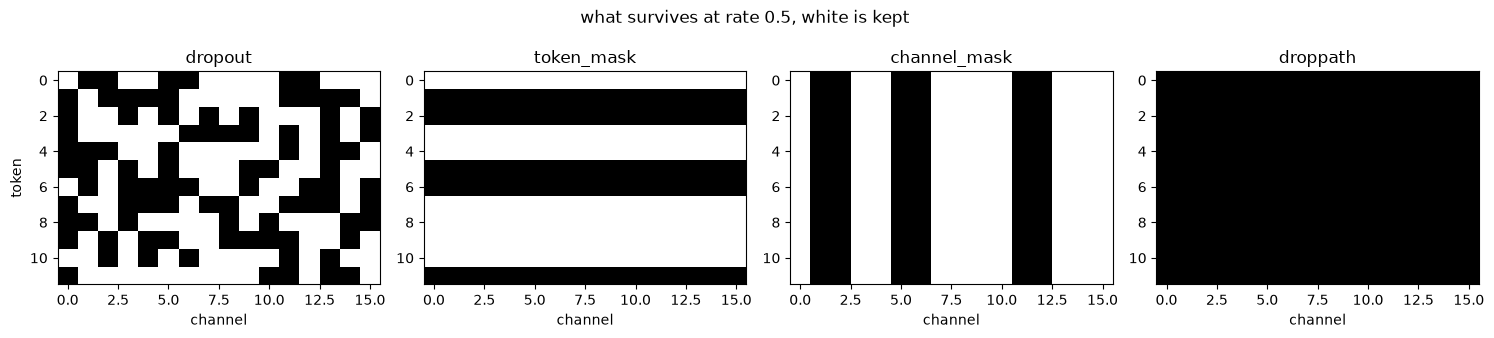

In [7]:
def show_mask_pattern(name, rate=0.5, seed=0):
    torch.manual_seed(seed)
    module = build_perturbation(name)(rate).train()
    return (module(torch.ones(1, 12, 16)) != 0).squeeze(0).numpy()


figure, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for axis, name in zip(axes, ("dropout", "token_mask", "channel_mask", "droppath")):
    axis.imshow(show_mask_pattern(name), cmap="Greys_r", aspect="auto", interpolation="nearest")
    axis.set_title(name)
    axis.set_xlabel("channel")
axes[0].set_ylabel("token")
figure.suptitle("what survives at rate 0.5, white is kept")
figure.tight_layout()
plt.show()

The structure is the whole point. `dropout` removes scattered elements,
`token_mask` removes whole rows (entire patches, so the model loses that image
region completely), `channel_mask` removes whole columns (a residual-stream
feature across every token), and `droppath` is all or nothing per sample. These
are 4 different hypotheses about what a transformer's redundancy looks like.

`token_mask` never masks token 0 on ViT, because that is the class token the head
reads. Removing it would not test redundancy, it would delete the prediction.

### Stochastic against deterministic operators

PSU is an expectation over `k` perturbed passes. For an operator whose output is a
deterministic function of its input, every pass returns the same value, so the
expectation is exact at `k = 1` and a `k > 1` sweep writes `k` identical rows.

In [8]:
torch.manual_seed(0)
sample = torch.randn(2, 6, 8)

rows = []
for name in PERTURBATIONS:
    if name in PERTURBATION_POSITIONS:
        continue  # needs a specific position's tensor layout
    module = build_perturbation(name)(0.3).train()
    first, second = module(sample), module(sample)
    rows.append(
        {
            "operator": name,
            "declared_deterministic": name in DETERMINISTIC_PERTURBATIONS,
            "two_passes_identical": bool(torch.equal(first, second)),
        }
    )
pd.DataFrame(rows)

,operator,declared_deterministic,two_passes_identical
0,dropout,False,False
1,channel_mask,False,False
2,token_mask,False,False
3,gaussian,False,False
4,rademacher,False,False
5,gain_scale,True,True


The declaration and the measurement must agree. They do, and `psbd.operators.effective_forward_passes`
uses the declaration to short-circuit `k` to 1 for the deterministic operators,
which is a pure cost saving and changes no number.

## Part 3. Why the 2 axes cannot be compared independently

A position and an operator do not produce comparable perturbations at the same
nominal rate. Rate 0.3 of `token_mask` at the attention input is not the same
amount of disturbance as rate 0.3 of `dropout` at the MLP output.

The quantity that makes them comparable is the **shift ratio**, sigma, the
fraction of perturbed passes whose prediction differs from the unperturbed one,
measured on the clean validation split:

$$\sigma(D) = \frac{1}{k \, |D|} \sum_{x \in D} \sum_{i=1}^{k} \mathbb{I}\left(Y(x; \theta) \neq Y(x; \theta_i')\right)$$

Sigma is a property of the disturbance as the model experiences it, not of the
knob that produced it. Comparing 2 placements at a matched sigma is the only fair
comparison, and the rest of this notebook measures why.

In [9]:
from psbd.inference import build_baseline_cache, compute_dropout_pass_probs
from psbd.models import detect_architecture, load_checkpoint
from psbd.scores import psu_from_cache, shift_ratio
from psbd.splits import build_psbd_loaders_from_checkpoint

CHECKPOINT = "checkpoints/vit_cifar100_badnet_a2o_0_01/attack_result.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loaders, manifest = build_psbd_loaders_from_checkpoint(CHECKPOINT, max_samples=512)
architecture = detect_architecture(CHECKPOINT)
model = load_checkpoint(architecture, CHECKPOINT, device)

print("splits:", {name: len(loader.dataset) for name, loader in loaders.items()})
print("architecture:", architecture)

/lustre/home/pstika/projects/PSBD-ViT/.venv/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


splits: {'validation': 512, 'clean': 512, 'backdoor': 506}
architecture: vit


In [10]:
# The unperturbed state of each split, computed once. Every PSU is measured
# against this, so it must be built before any probe is attached.
baselines = {
    name: build_baseline_cache(model, loader, device, use_bfloat16=True)
    for name, loader in loaders.items()
}
baseline_labels = {
    name: torch.cat([batch["labels"] for batch in cache]) for name, cache in baselines.items()
}
{name: tuple(labels.shape) for name, labels in baseline_labels.items()}

{'validation': (512,), 'clean': (512,), 'backdoor': (506,)}

In [11]:
FORWARD_PASSES = 4
RATES = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7)
COMPARED = [
    ("before_attention_norm", "token_mask"),
    ("before_mlp", "token_mask"),
    ("before_mlp", "dropout"),
    ("after_embedding", "token_mask"),
]

sweep_rows = []
for position, operator in COMPARED:
    for rate in RATES:
        handles = plug_dropout(
            model, architecture, (position,), {position: build_perturbation(operator)}, rate
        )
        try:
            measured = {}
            for split in ("validation", "clean", "backdoor"):
                if split not in loaders:
                    continue
                probs, argmax = compute_dropout_pass_probs(
                    model, loaders[split], baseline_labels[split], device,
                    FORWARD_PASSES, True, seed=0,
                )
                measured[split] = {
                    "sigma": shift_ratio(baseline_labels[split], argmax),
                    "psu": psu_from_cache(
                        torch.cat([b["probs"] for b in baselines[split]]),
                        baseline_labels[split],
                        probs,
                    ).mean().item(),
                }
        finally:
            unplug_dropout(handles)

        sweep_rows.append(
            {
                "position": position,
                "operator": operator,
                "rate": rate,
                "sigma_validation": measured["validation"]["sigma"],
                "psu_clean": measured["clean"]["psu"],
                "psu_backdoor": measured["backdoor"]["psu"],
            }
        )
    print(f"done {position} + {operator}")

sweep = pd.DataFrame(sweep_rows)
sweep.round(4)

done before_attention_norm + token_mask


done before_mlp + token_mask


done before_mlp + dropout


done after_embedding + token_mask


,position,operator,rate,sigma_validation,psu_clean,psu_backdoor
0,before_attention_norm,token_mask,0.1,0.1270,0.0939,0.0005
1,before_attention_norm,token_mask,0.2,0.2744,0.2962,0.0049
2,before_attention_norm,token_mask,0.3,0.4727,0.5141,0.0189
3,before_attention_norm,token_mask,0.4,0.6938,0.7275,0.0606
4,before_attention_norm,token_mask,0.5,0.8535,0.8571,0.1769
5,before_attention_norm,token_mask,0.6,0.9336,0.8985,0.3847
6,before_attention_norm,token_mask,0.7,0.9644,0.9084,0.6590
7,before_mlp,token_mask,0.1,0.1274,0.0644,0.0004
8,before_mlp,token_mask,0.2,0.2202,0.1448,0.0036
9,before_mlp,token_mask,0.3,0.3608,0.3338,0.0153


### The same rate is a different disturbance at every placement

Read the first panel across. At a nominal rate of 0.3 the placements sit at
completely different sigma, so any comparison made at fixed rate is comparing
different amounts of disturbance and attributing the difference to the placement.

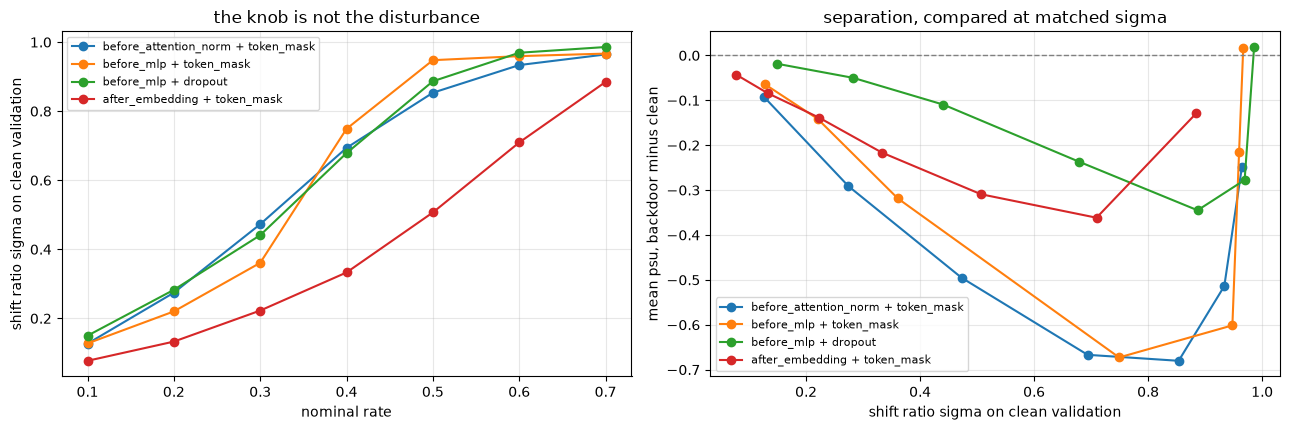

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for (position, operator), group in sweep.groupby(["position", "operator"], sort=False):
    label = f"{position} + {operator}"
    axes[0].plot(group["rate"], group["sigma_validation"], marker="o", label=label)
    axes[1].plot(
        group["sigma_validation"],
        group["psu_backdoor"] - group["psu_clean"],
        marker="o",
        label=label,
    )

axes[0].set_xlabel("nominal rate")
axes[0].set_ylabel("shift ratio sigma on clean validation")
axes[0].set_title("the knob is not the disturbance")
axes[1].set_xlabel("shift ratio sigma on clean validation")
axes[1].set_ylabel("mean psu, backdoor minus clean")
axes[1].set_title("separation, compared at matched sigma")
axes[1].axhline(0, ls="--", lw=1, c="grey")
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend(fontsize=8)
figure.tight_layout()
plt.show()

The right panel is the comparison that is actually fair. Both axes now describe
the model's experience rather than the knob setting, and placements can be read
against each other at the same x.

A negative value means backdoor samples lost *more* confidence than clean ones,
which is the opposite of PSBD's premise and shows up in the result set as an
AUROC below 0.5. Those inversions are real and are reported rather than hidden.

The threshold rule built on sigma is what `psbd.decision` implements, and
notebook 06 follows a single checkpoint all the way from these raw passes to a
detection verdict.